# Clasificación Convolutional Neural Networks


In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, Dropout, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1.Balancear dataset y Preprocesamiento de imágenes con keras

In [23]:
import os
import numpy as np

base_dir = '/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/chest_xray_preprocessed/train'
classes = ['NORMAL', 'PNEUMONIA']

normal_images = [os.path.join(base_dir, 'NORMAL', f)
                 for f in os.listdir(os.path.join(base_dir, 'NORMAL'))]

pneumonia_images = [os.path.join(base_dir, 'PNEUMONIA', f)
                    for f in os.listdir(os.path.join(base_dir, 'PNEUMONIA'))]


In [24]:
import numpy as np
import cv2

def preprocess_cxr(img):
    """
    img llega como (H, W, 3) float32 (0–255 o 0–1) desde Keras.
    Devolvemos float32 en [0,1] con CLAHE aplicado.
    """

    # Asegurar rango 0–255 y tipo uint8
    if img.max() <= 1.0:
        img = img * 255.0
    img = img.astype(np.uint8)

    # Si viniera en escala de grises (H,W,1), replicamos canales
    if img.ndim == 3 and img.shape[-1] == 1:
        img = np.repeat(img, 3, axis=-1)

    # CLAHE sobre el canal L en espacio LAB
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)

    limg = cv2.merge((cl, a, b))
    img_clahe = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    # Normalizar a [0,1] float32
    img_clahe = img_clahe.astype(np.float32) / 255.0

    return img_clahe


In [25]:
#Balancear el dataset
min_count = min(len(normal_images), len(pneumonia_images))

np.random.shuffle(normal_images)
np.random.shuffle(pneumonia_images)

normal_balanced = normal_images[:min_count]
pneumonia_balanced = pneumonia_images[:min_count]

balanced_paths = np.array(normal_balanced + pneumonia_balanced)
balanced_labels = np.array([0]*min_count + [1]*min_count)

# Mezclar datos
idx = np.random.permutation(len(balanced_paths))
balanced_paths = balanced_paths[idx]
balanced_labels = balanced_labels[idx]



df_balanced = pd.DataFrame({
    "filename": balanced_paths,
    "class": balanced_labels
})


In [26]:
# Create an ImageDataGenerator for rescaling images
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_cxr,
    #rescale=1./255,
    validation_split=0.2
)

train = datagen.flow_from_dataframe(
    dataframe=df_balanced,
    x_col="filename",
    y_col="class",
    target_size=(150, 150),
    batch_size=32,
    class_mode="raw",      # porque y son 0/1 numéricos
    subset="training",
    shuffle=True
)

val = datagen.flow_from_dataframe(
    dataframe=df_balanced,
    x_col="filename",
    y_col="class",
    target_size=(150, 150),
    batch_size=32,
    class_mode="raw",
    subset="validation",
    shuffle=False
)

Found 2146 validated image filenames.
Found 536 validated image filenames.


In [27]:
# Create an ImageDataGenerator for rescaling images
datagen = ImageDataGenerator(preprocessing_function=preprocess_cxr)

# Load test data
test = datagen.flow_from_directory(
    directory='/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/chest_xray_preprocessed/test',
    target_size=(150, 150),
    color_mode="rgb",
    batch_size=32,
    class_mode="binary"
)


Found 624 images belonging to 2 classes.


## 2. Construir el modelo CNN

Includes convolutional layers, max-pooling, and fully connected layers.

In [28]:
# Initialize the model
classifier = Sequential()

# Convolution layer 1
classifier.add(Conv2D(32, (3, 3), input_shape=(150, 150, 3), activation='relu', padding='same'))
classifier.add(MaxPooling2D(strides=(2,2), pool_size=(2, 2)))

# Convolution layer 2
classifier.add(Conv2D(64, (3, 3), activation='relu'))
classifier.add(MaxPooling2D(strides=(2,2), pool_size=(2, 2)))

# Convolution layer 3
classifier.add(Conv2D(128, (3, 3), activation='relu'))
classifier.add(MaxPooling2D(strides=(2,2), pool_size=(2, 2)))

# Convolution layer 4
#classifier.add(Conv2D(128, (3, 3), activation='relu'))
#classifier.add(MaxPooling2D(strides=(2,2), pool_size=(2, 2)))

# Flatten the results from convolutional layers
classifier.add(Flatten())

# Fully connected layer
classifier.add(Dense(units=128, activation='relu'))
classifier.add(Dropout(0.25))

# Output layer
classifier.add(Dense(units=1, activation='sigmoid'))

# Compile the model
classifier.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 3. Entrenamiento del modelo

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1028s 15s/step - accuracy: 0.5762 - loss: 0.6854 - val_accuracy: 0.9198 - val_loss: 0.4309
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 207ms/step - accuracy: 0.8772 - loss: 0.3720 - val_accuracy: 0.9534 - val_loss: 0.1722
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 211ms/step - accuracy: 0.9425 - loss: 0.1825 - val_accuracy: 0.9664 - val_loss: 0.1103
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 209ms/step - accuracy: 0.9509 - loss: 0.1413 - val_accuracy: 0.8955 - val_loss: 0.2556
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 245ms/step - accuracy: 0.9454 - loss: 0.1523 - val_accuracy: 0.9627 - val_loss: 0.0822
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 206ms/step - accuracy: 0.9586 - loss: 0.1144 - val_accuracy: 0.9403 - val_loss: 0.1529
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 16s 233ms/step - accuracy: 0.9533 - loss: 0.1260 - val_accuracy: 0.9701 - val_loss: 0.0764
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 203ms/step - accuracy: 0.9624 - loss: 0.0988 - val_accu

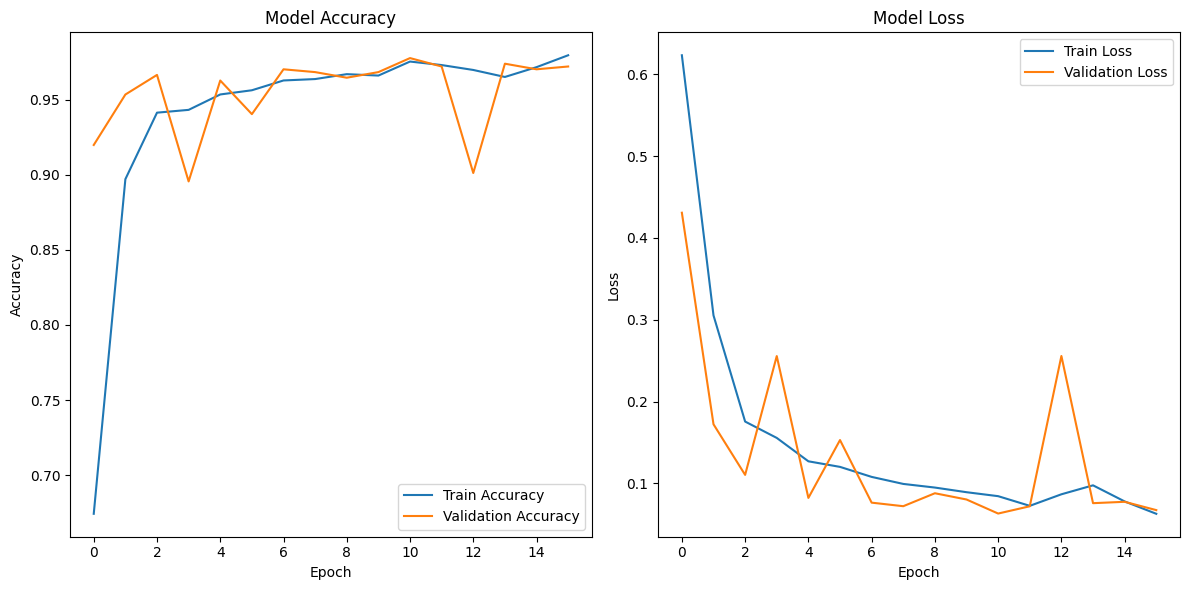

In [29]:
from sklearn.utils import class_weight
import numpy as np


early = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the model and capture the history
history = classifier.fit(
    train,
    epochs=20,
    validation_data=val,
    #class_weight=class_weights,
    callbacks=[early],
)

# Plotting training & validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='best')

# Show the plot
plt.tight_layout()
plt.show()


## 4. Métricas

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

preds = classifier.predict(test).ravel()
preds_bin = (preds >= 0.5).astype(int)

y_true = test.classes

print(classification_report(y_true, preds_bin))


20/20 ━━━━━━━━━━━━━━━━━━━━ 443s 23s/step
              precision    recall  f1-score   support

           0       0.42      0.22      0.29       234
           1       0.64      0.82      0.72       390

    accuracy                           0.59       624
   macro avg       0.53      0.52      0.50       624
weighted avg       0.56      0.59      0.56       624



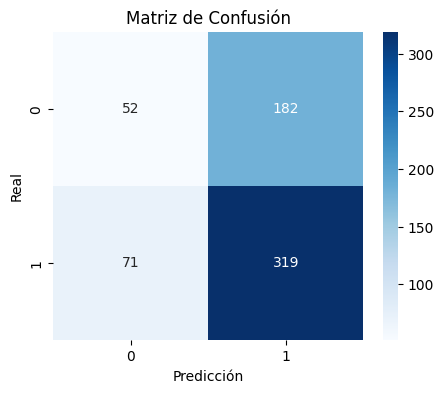

In [31]:
#Matriz de confusión
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, preds_bin)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()


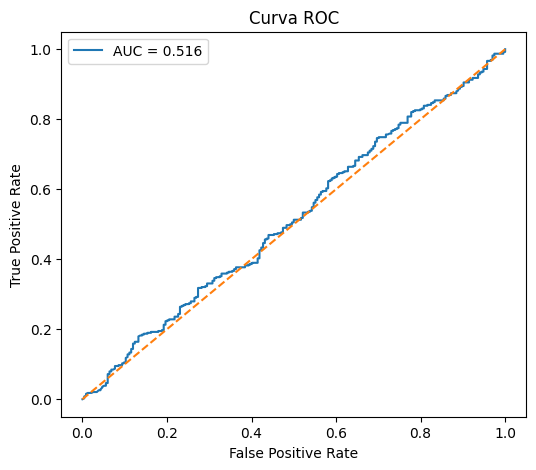

In [32]:
#CURVA ROC + AUC

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()


## 5. Prueba utilizando EfficientNetB0

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)

base_model.trainable = False  # etapa 1: congelado

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#Early_Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#Fitting Model
history = model.fit(train,
                    epochs= 50,
                    validation_data = val,
                    callbacks = [early_stopping])

# Plotting training & validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='best')

# Show the plot
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
24/68 ━━━━━━━━━━━━━━━━━━━━ 6:33 9s/step - accuracy: 0.4768 - loss: 0.9029

KeyboardInterrupt: 

In [ ]:
#Metricas

from sklearn.metrics import classification_report, confusion_matrix

preds = model.predict(test).ravel()
preds_bin = (preds >= 0.5).astype(int)

y_true = test.classes

print(classification_report(y_true, preds_bin))


10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 776ms/step
              precision    recall  f1-score   support

           0       0.34      0.16      0.22       234
           1       0.62      0.81      0.70       390

    accuracy                           0.57       624
   macro avg       0.48      0.49      0.46       624
weighted avg       0.51      0.57      0.52       624



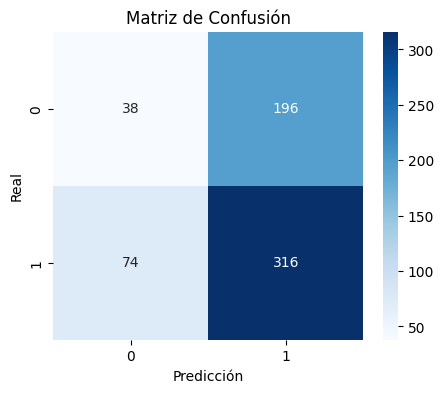

In [ ]:
#Matriz de confusión
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, preds_bin)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()
